# Cape Cauldron shear lines against the GLED eddy atlas

GLED v1.0 (Liu & Abernathey 2023,
[doi:10.5194/essd-15-1765-2023](https://doi.org/10.5194/essd-15-1765-2023),
data [doi:10.5281/zenodo.7349753](https://doi.org/10.5281/zenodo.7349753))
lists coherent Lagrangian eddies found from the Lagrangian averaged vorticity
deviation (Haller et al. 2016, J. Fluid Mech. 795,
[doi:10.1017/jfm.2016.151](https://doi.org/10.1017/jfm.2016.151)) on
trajectories advected with DUACS altimetry geostrophic currents. Its windows
are 30 days long and start on the first of each month, and it gives each
eddy's centre and radius at the release time.

This notebook runs the closed-shear-line search of `cape_cauldron_vortices`
on three surface current fields over the GLED window from 2018-06-01:

- the DUACS geostrophic currents GLED is computed on,
- the GLORYS12 reanalysis daily currents,
- the geostrophic currents of GLORYS12's own sea surface height.

GLORYS12 assimilates along-track altimetry rather than the DUACS maps
(Lellouche et al. 2021,
[doi:10.3389/feart.2021.698876](https://doi.org/10.3389/feart.2021.698876)),
so its eddies need not sit where GLED's do. The search therefore runs at
windows of 10 to 30 days, and the number of boundaries each field yields is
read alongside the matches with GLED.

In [1]:
# Importing Parcels pulls in the holoviews/bokeh bootstrap and prints an
# alpha-version notice, neither of which belongs on the rendered page.
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from parcels import FieldSet, Particle, ParticleSet, StatusCode
from parcels.convert import copernicusmarine_to_sgrid
from parcels.kernels import AdvectionRK4

from lcs_parcels import NeighborSeedGrid, closed_shear_lines, outermost_shear_lines

/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_55890/2240645360.py:9: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  from parcels import FieldSet, Particle, ParticleSet, StatusCode


## Currents

The DUACS daily geostrophic velocity at 1/8 degree and the GLORYS12 daily
surface currents and sea surface height at 1/12 degree, the local files that
`get_data` writes.

In [2]:
duacs = xr.open_dataset("data/cape_cauldron_geostrophic_daily.nc").load()
duacs

<xarray.Dataset> Size: 40MB
Dimensions:    (time: 34, latitude: 256, longitude: 288)
Coordinates:
  * time       (time) datetime64[ns] 272B 2018-05-31 2018-06-01 ... 2018-07-03
  * latitude   (latitude) float32 1kB -51.94 -51.81 -51.69 ... -20.19 -20.06
  * longitude  (longitude) float32 1kB -5.938 -5.812 -5.688 ... 29.81 29.94
Data variables:
    ugos       (time, latitude, longitude) float64 20MB 0.04 0.0458 ... nan nan
    vgos       (time, latitude, longitude) float64 20MB 0.0334 0.0395 ... nan
Attributes: (12/43)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    time_coverage_duration:          P1D
    time_coverage_end:               2023-12-31T12:00:00Z
    time_coverage_resolution:        P1D
    time_coverage_start:             2023-12-30T12:00:00Z
    title:                           DT merged all satellites Global Ocean Gr...
    copernicusmarine_version:        2.4.1

In [3]:
glorys = xr.open_dataset("data/cape_cauldron_glorys_daily.nc").load()
glorys

<xarray.Dataset> Size: 136MB
Dimensions:    (time: 34, depth: 1, latitude: 385, longitude: 433)
Coordinates:
  * time       (time) datetime64[ns] 272B 2018-05-31 2018-06-01 ... 2018-07-03
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 2kB -52.0 -51.92 -51.83 ... -20.08 -20.0
  * longitude  (longitude) float32 2kB -6.0 -5.917 -5.833 ... 29.83 29.92 30.0
Data variables:
    uo         (time, depth, latitude, longitude) float64 45MB 0.07508 ... nan
    vo         (time, depth, latitude, longitude) float64 45MB 0.05005 ... nan
    zos        (time, latitude, longitude) float64 45MB -1.443 -1.442 ... nan
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Physics An...
    z_max:                     5727.9169921875
    z_min:                     0.49402499198913574
    copernicusmarine_version:  2.4.1

The geostrophic velocity of GLORYS12's sea surface height $\eta$ is
$u_g = -(g/f)\,\partial_y \eta$, $v_g = (g/f)\,\partial_x \eta$, with
$f = 2\Omega \sin\phi$. Like the DUACS product used here, it keeps the
divergence the latitude dependence of $f$ gives it.

In [4]:
earth_radius_m = 6_371_000.0
f = 2 * 7.2921e-5 * np.sin(np.deg2rad(glorys["latitude"]))
deta_dx = glorys["zos"].differentiate("longitude") / (
    earth_radius_m * np.cos(np.deg2rad(glorys["latitude"])) * np.deg2rad(1.0)
)
deta_dy = glorys["zos"].differentiate("latitude") / (earth_radius_m * np.deg2rad(1.0))
glorys_geostrophic = xr.Dataset(
    {"ugos": -9.81 / f * deta_dy, "vgos": 9.81 / f * deta_dx}
)

## Parcels v4 field sets

The geostrophic fields carry no depth coordinate, so their particles are
released with no `z`. The GLORYS12 currents are released at their one depth
level.

In [5]:
fieldsets = {
    "DUACS": FieldSet.from_sgrid_conventions(
        copernicusmarine_to_sgrid(fields={"U": duacs["ugos"], "V": duacs["vgos"]}),
        mesh="spherical",
    ),
    "GLORYS12": FieldSet.from_sgrid_conventions(
        copernicusmarine_to_sgrid(fields={"U": glorys["uo"], "V": glorys["vo"]}),
        mesh="spherical",
    ),
    "GLORYS12 geostrophic": FieldSet.from_sgrid_conventions(
        copernicusmarine_to_sgrid(
            fields={
                "U": glorys_geostrophic["ugos"],
                "V": glorys_geostrophic["vgos"],
            }
        ),
        mesh="spherical",
    ),
}
release_depth = {
    "DUACS": None,
    "GLORYS12": float(glorys["depth"].values[0]),
    "GLORYS12 geostrophic": None,
}

## Seed grid and windows

The GLED box at 1/25 degree, released on 2018-06-01 at 00:00. The 30-day
window is GLED's own.

In [6]:
t0 = np.datetime64("2018-06-01")
windows_days = [10, 15, 20, 30]
seed = NeighborSeedGrid.from_axes(
    lon=np.arange(2.0, 22.0 + 1e-9, 1 / 25), lat=np.arange(-44.0, -28.0 + 1e-9, 1 / 25)
)
seed

<NeighborSeedGrid 501x401 grid, lon 2.00..22.00, lat -44.00..-28.00>

## Recovery kernel

Particles that leave the domain or hit land are turned into `NaN` in place
(Parcels would otherwise abort the run), so losses propagate as `NaN`
through every diagnostic below. The kernel sets `StatusCode.EndofLoop`
rather than `StatusCode.Delete`, because deleting shrinks the particle
array and breaks the alignment with the seed order.

In [7]:
def set_lost_to_nan(particles, fieldset):
    lost = particles.state >= StatusCode.Error
    particles.x = np.where(lost, np.nan, particles.x)
    particles.y = np.where(lost, np.nan, particles.y)
    particles.state = np.where(lost, StatusCode.EndofLoop, particles.state)

## Advection

One forward run per field and window, each released from the seed grid.

In [8]:
def advect(field, *, days):
    lon, lat = seed.to_parcels_pset()
    depth = release_depth[field]
    z = {} if depth is None else {"z": np.full(len(lon), depth)}
    pset = ParticleSet(fieldsets[field], pclass=Particle, x=lon, y=lat, t=t0, **z)
    pset.execute(
        [AdvectionRK4, set_lost_to_nan],
        dt=np.timedelta64(1, "h"),
        runtime=np.timedelta64(days, "D"),
        verbose_progress=False,
    )
    return seed.pset_to_flowmap(
        lon=pset.x, lat=pset.y, t0=t0, t1=t0 + np.timedelta64(days, "D")
    )

## The GLED records

`eddy_info_30d.json` and `eddy_info_90d.json` each map an eddy id to its
`date_start`, `radius` in km, polarity `cyc`, and centre position sampled
every 10 days. Index 0 of `center_lon`/`center_lat` is the position at the
start date, which is what selects an eddy into the box here.

In [9]:
def load_gled(path, *, date_start, lon_bounds, lat_bounds):
    """GLED eddies starting on `date_start` whose start position is in the box."""
    with open(path) as f:
        raw = json.load(f)
    ids, gled_lon, gled_lat, radius_km, polarity = [], [], [], [], []
    for key, start in raw["date_start"].items():
        if start != date_start:
            continue
        # GLED stores 0-360 longitudes, and this box is east of Greenwich.
        lon_0 = ((raw["center_lon"][key][0] + 180.0) % 360.0) - 180.0
        lat_0 = raw["center_lat"][key][0]
        if not (lon_bounds[0] <= lon_0 <= lon_bounds[1]):
            continue
        if not (lat_bounds[0] <= lat_0 <= lat_bounds[1]):
            continue
        ids.append(raw["id"][key])
        gled_lon.append(lon_0)
        gled_lat.append(lat_0)
        radius_km.append(raw["radius"][key])
        polarity.append(raw["cyc"][key])
    return xr.Dataset(
        {
            "lon": (
                "gled",
                np.array(gled_lon, dtype=float),
                {"long_name": "GLED eddy centre longitude", "units": "degrees_east"},
            ),
            "lat": (
                "gled",
                np.array(gled_lat, dtype=float),
                {"long_name": "GLED eddy centre latitude", "units": "degrees_north"},
            ),
            "radius_m": (
                "gled",
                np.array(radius_km, dtype=float) * 1000.0,
                {"long_name": "GLED eddy radius", "units": "m"},
            ),
            "polarity": (
                "gled",
                np.array(polarity, dtype=int),
                {
                    "long_name": "GLED eddy polarity, 1 anticyclonic and -1 cyclonic",
                    "units": "1",
                },
            ),
        },
        coords={"gled": ("gled", ids, {"long_name": "GLED eddy identifier"})},
    )

In [10]:
gled_30 = load_gled(
    "data/gled/eddyinfo/eddy_info_30d.json",
    date_start="2018-06-01",
    lon_bounds=(2.0, 22.0),
    lat_bounds=(-44.0, -28.0),
)
gled_90 = load_gled(
    "data/gled/eddyinfo/eddy_info_90d.json",
    date_start="2018-06-01",
    lon_bounds=(2.0, 22.0),
    lat_bounds=(-44.0, -28.0),
)
gled_30

<xarray.Dataset> Size: 3kB
Dimensions:   (gled: 23)
Coordinates:
  * gled      (gled) <U24 2kB '2018-06-01_030day_000047' ... '2018-06-01_030d...
Data variables:
    lon       (gled) float64 184B 15.73 13.67 8.516 14.42 ... 7.297 2.891 2.047
    lat       (gled) float64 184B -39.58 -35.3 -40.48 ... -43.17 -30.42 -38.52
    radius_m  (gled) float64 184B 7.25e+04 8.009e+04 ... 2.797e+04 3.098e+04
    polarity  (gled) int64 184B 1 -1 1 1 1 1 -1 -1 -1 1 ... 1 1 1 1 1 -1 1 -1 1

## Are the GLED eddies in each field?

The relative vorticity on 2018-06-01, averaged within a third of each GLED
eddy's radius of its centre. GLED's polarity is $+1$ anticyclonic, which in
the southern hemisphere is positive vorticity. The strength is that mean over
the field's root-mean-square vorticity in the box.

In [11]:
def relative_vorticity(u, v):
    cos_lat = np.cos(np.deg2rad(u["latitude"]))
    return v.differentiate("longitude") / (
        earth_radius_m * cos_lat * np.deg2rad(1.0)
    ) - u.differentiate("latitude") / (earth_radius_m * np.deg2rad(1.0))


day_0 = {
    "DUACS": relative_vorticity(duacs["ugos"], duacs["vgos"]),
    "GLORYS12": relative_vorticity(glorys["uo"], glorys["vo"]).squeeze("depth"),
    "GLORYS12 geostrophic": relative_vorticity(
        glorys_geostrophic["ugos"], glorys_geostrophic["vgos"]
    ),
}
box = {"longitude": slice(2.0, 22.0), "latitude": slice(-44.0, -28.0)}
rows = {}
for field, vorticity in day_0.items():
    vorticity = vorticity.sel(time=t0).sel(**box)
    rms = float(np.sqrt((vorticity**2).mean()))
    agree, strength = 0, []
    for e in range(gled_30.sizes["gled"]):
        eddy = gled_30.isel(gled=e)
        half_lat = float(eddy["radius_m"]) / 3 / 111_195.0
        half_lon = half_lat / np.cos(np.deg2rad(float(eddy["lat"])))
        core = vorticity.sel(
            longitude=slice(
                float(eddy["lon"]) - half_lon, float(eddy["lon"]) + half_lon
            ),
            latitude=slice(
                float(eddy["lat"]) - half_lat, float(eddy["lat"]) + half_lat
            ),
        ).mean()
        agree += int(np.sign(float(core)) == int(eddy["polarity"]))
        strength.append(abs(float(core)) / rms)
    rows[field] = {
        "sign matches GLED": agree,
        "core strength, median": float(np.median(strength)),
    }
pd.DataFrame(rows).round(2)

,DUACS,GLORYS12,GLORYS12 geostrophic
sign matches GLED,23.00,17.00,18.00
"core strength, median",1.48,0.54,0.59


## Matching

A GLED eddy is matched when the centroid of a boundary lies within its
radius. In the southern hemisphere a counter-clockwise eddy is anticyclonic,
so `rotation_sense` is GLED's polarity there.

In [12]:
def distance_m(*, lon_a, lat_a, lon_b, lat_b):
    lat_mid = np.deg2rad(0.5 * (lat_a + lat_b))
    dx = 6_371_000.0 * np.cos(lat_mid) * np.deg2rad(lon_b - lon_a)
    dy = 6_371_000.0 * np.deg2rad(lat_b - lat_a)
    return np.hypot(dx, dy)


def match_to_gled(eddies, *, gled):
    """One row per GLED eddy with the nearest boundary, distances and radii in km."""
    if eddies.sizes["eddy"] == 0:
        return pd.DataFrame(
            {"matched": False, "same_polarity": np.nan}, index=gled["gled"].values
        )
    distance = distance_m(
        lon_a=gled["lon"],
        lat_a=gled["lat"],
        lon_b=eddies["centroid_lon"],
        lat_b=eddies["centroid_lat"],
    )
    nearest = eddies.isel(eddy=distance.argmin("eddy"))
    return pd.DataFrame(
        {
            "gled_lon": gled["lon"].values,
            "gled_lat": gled["lat"].values,
            "gled_radius_km": gled["radius_m"].values / 1000,
            "distance_km": distance.min("eddy").values / 1000,
            "radius_km": nearest["radius_m"].values / 1000,
            "stretch": nearest["stretch"].values,
            "matched": (distance.min("eddy") <= gled["radius_m"]).values,
            "same_polarity": (
                (nearest["rotation_sense"] == gled["polarity"]).values
                if "rotation_sense" in nearest
                else np.nan
            ),
        },
        index=gled["gled"].values,
    )

## The search over fields and windows

For each field and window, sweep A runs `elliptic_lcs`, which picks its own
candidate centres, and sweep B launches the same search from the GLED
centres. Sweep B's boundaries take their rotation sense from a 1-day flow map
of the same field, since the polar rotation angle is defined modulo $2\pi$.

In [13]:
first_day = {field: advect(field, days=1) for field in fieldsets}

In [14]:
results = []
last = {}
for field in fieldsets:
    for days in windows_days:
        forward = advect(field, days=days)
        grad_f = forward.deformation_gradient()
        det = abs(
            grad_f.sel(row="x", col="x") * grad_f.sel(row="y", col="y")
            - grad_f.sel(row="x", col="y") * grad_f.sel(row="y", col="x")
        )
        eddies_a = forward.elliptic_lcs()
        eddies_b = outermost_shear_lines(
            closed_shear_lines(
                forward, centre_lon=gled_30["lon"], centre_lat=gled_30["lat"]
            ),
            rotation=first_day[field].polar_rotation(),
        )
        matched_a = match_to_gled(eddies_a, gled=gled_30)["matched"]
        rows_b = match_to_gled(eddies_b, gled=gled_30)
        matched_b = rows_b[rows_b["matched"]]
        results.append(
            {
                "field": field,
                "window (days)": days,
                "median |det grad F|": float(det.median()),
                "boundaries, A": eddies_a.sizes["eddy"],
                "GLED matched, A": int(matched_a.sum()),
                "GLED matched, B": len(matched_b),
                "same polarity, B": int(matched_b["same_polarity"].sum()),
            }
        )
        last[field] = (eddies_a, eddies_b)

In [15]:
summary = pd.DataFrame(results).set_index(["field", "window (days)"])
summary.round(2)

median |det grad F|  boundaries, A  \
field                window (days)                                       
DUACS                10                            1.02             45   
                     15                            1.06             29   
                     20                            1.17             21   
                     30                            3.38             11   
GLORYS12             10                            1.03             21   
                     15                            1.28             12   
                     20                            2.05              4   
                     30                           11.12              0   
GLORYS12 geostrophic 10                            1.04             27   
                     15                            1.20             19   
                     20                            2.10             11   
                     30                           12.09              4   

                                    GLED matched, A  GLED matched, B  \
field                window (days)                                     
DUACS                10                          13               11   
                     15                          11               13   
                     20                           8               12   
                     30                           7                9   
GLORYS12             10                           7                5   
                     15                           4                2   
                     20                           2                2   
                     30                           0                0   
GLORYS12 geostrophic 10                           6                6   
                     15                           5                4   
                     20                           5                2   
                     30                           2                1   

                                    same polarity, B  
field                window (days)                    
DUACS                10                           11  
                     15                           13  
                     20                           12  
                     30                            9  
GLORYS12             10                            5  
                     15                            2  
                     20                            2  
                     30                            0  
GLORYS12 geostrophic 10                            6  
                     15                            4  
                     20                            2  
                     30                            1

The number of boundaries each field yields against the window. It counts the
field's own coherent loops, with no reference to GLED.

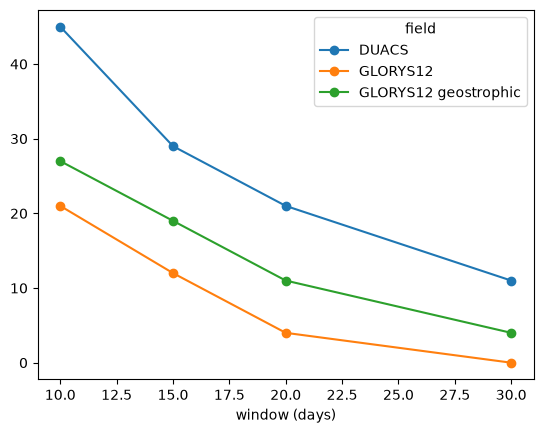

In [16]:
summary["boundaries, A"].unstack("field").plot(marker="o")
plt.show()

## GLED and the closed shear lines at 30 days

The GLED eddies as circles at their radius, blue for cyclonic and red for
anticyclonic, with a thick outline where the 90-day product carries the eddy
too. A 90-day eddy is coherent over three times the window here, so its
outline marks persistence and not a 30-day boundary. The boundaries of sweep A
are drawn solid and those of sweep B dashed, over the decimal logarithm of the
eigenvalue ratio the sweep-A centres were picked from, its colour range clipped
to the 2nd to 98th percentile so the grid-scale speckle does not set it.

In [17]:
def plot_against_gled(eddies_a, eddies_b):
    angle = np.linspace(0.0, 2 * np.pi, 200)
    _, ax = plt.subplots(figsize=(11, 8))
    np.log10(eddies_a["cg_anisotropy"]).assign_attrs(
        long_name="log10 of the Cauchy-Green eigenvalue ratio lambda_2 / lambda_1",
        units="1",
    ).plot.pcolormesh(x="lon_grid", y="lat_grid", ax=ax, cmap="Greys", robust=True)
    for records, width in ((gled_30, 1.2), (gled_90, 3.0)):
        for e in range(records.sizes["gled"]):
            eddy = records.isel(gled=e)
            radius_deg = float(eddy["radius_m"]) / 111_195.0
            ax.plot(
                float(eddy["lon"])
                + radius_deg * np.cos(angle) / np.cos(np.deg2rad(float(eddy["lat"]))),
                float(eddy["lat"]) + radius_deg * np.sin(angle),
                color="tab:red" if int(eddy["polarity"]) > 0 else "tab:blue",
                lw=width,
            )
    ax.plot(eddies_a["lon"].T, eddies_a["lat"].T, color="tab:green", lw=2.0)
    ax.plot(eddies_b["lon"].T, eddies_b["lat"].T, color="tab:green", lw=2.0, ls="--")
    plt.show()

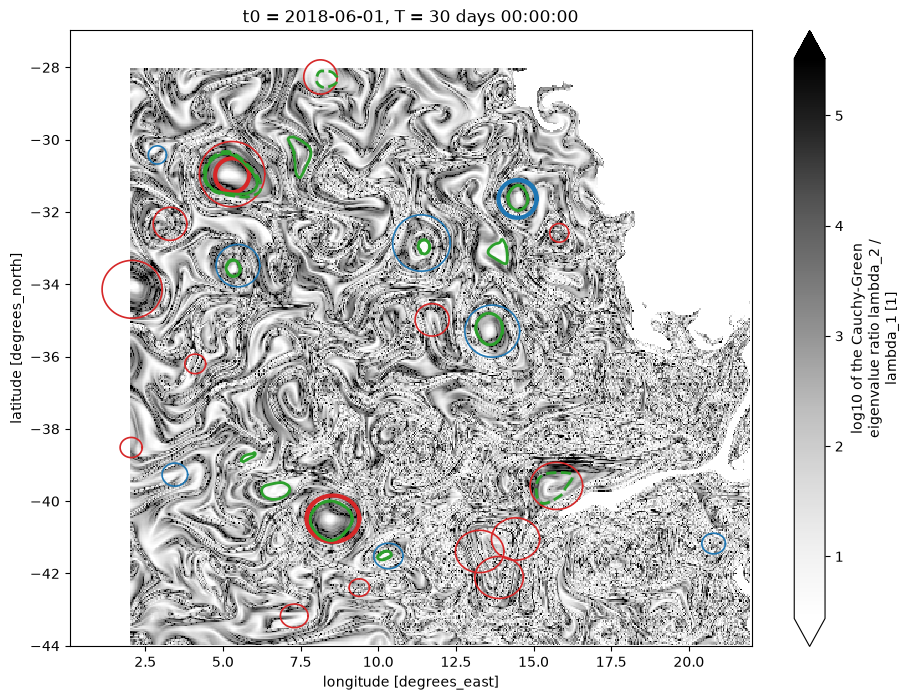

In [18]:
plot_against_gled(*last["DUACS"])

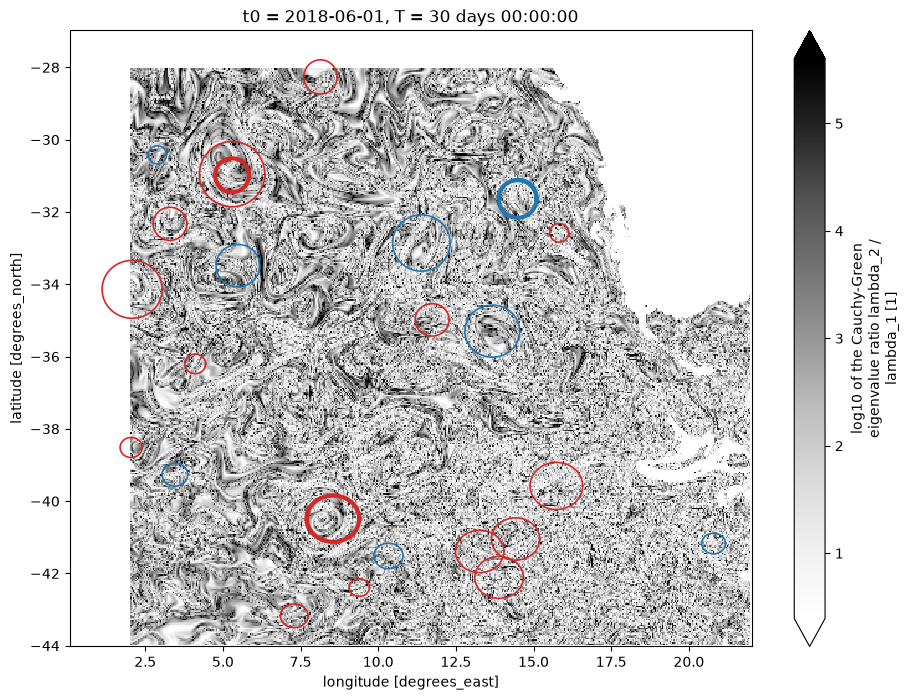

In [19]:
plot_against_gled(*last["GLORYS12"])

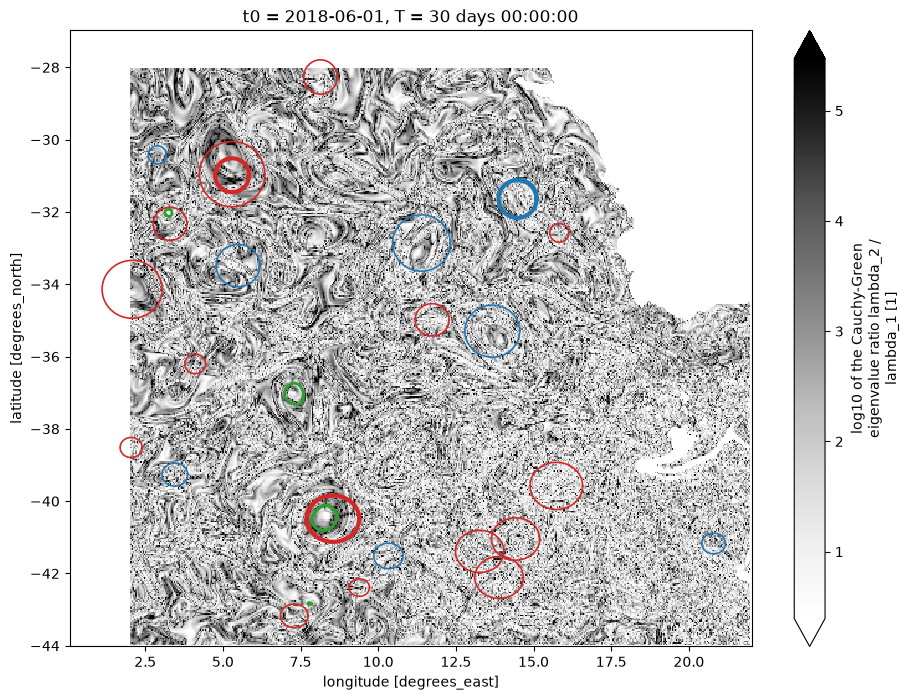

In [20]:
plot_against_gled(*last["GLORYS12 geostrophic"])

## Outcome

GLED places 23 eddies in the box on 1 June 2018. The DUACS vorticity at their
centres has GLED's sign at all 23, with a median core strength of 1.48 times
the field's rms. GLORYS12 has it at 17, and its geostrophic part at 18, with
median core strengths of 0.54 and 0.59.

The number of boundaries falls with the window in every field, from 45 at
10 days to 11 at 30 days in DUACS, from 27 to 4 in the GLORYS12 geostrophic
currents, and from 21 to 0 in the GLORYS12 currents. The median
$|\det \nabla F|$ stays within 0.3 of 1 up to 20 days in DUACS and up to 15
days in both GLORYS12 fields, and reaches 3.38 in DUACS and 11.12 and 12.09
in GLORYS12 at 30 days.

At GLED's 30-day window, sweep A matches 7 GLED eddies in DUACS, 0 in the
GLORYS12 currents and 2 in their geostrophic part. Launched from the GLED
centres, sweep B closes a boundary at 9, 0 and 1 of them. Every boundary
sweep B matches, in every field and window, turns over the first day in the
sense GLED's polarity gives.